In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/staging/stg_dataco_shipments.csv")

df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,lead_time_days
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,3
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,5
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,4
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,3
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  str    
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  str    
 6   late_delivery_risk           180519 non-null  int64  
 7   category_id                  180519 non-null  int64  
 8   category_name                180519 non-null  str    
 9   customer_city                180519 non-null  str    
 10  customer_country             180519 non-null  str    
 11  customer_email               180519 non-null  str    
 12  customer_fname               180519 non-null  str    
 13  customer_i

type                                0
days_for_shipping_real              0
days_for_shipment_scheduled         0
benefit_per_order                   0
sales_per_customer                  0
delivery_status                     0
late_delivery_risk                  0
category_id                         0
category_name                       0
customer_city                       0
customer_country                    0
customer_email                      0
customer_fname                      0
customer_id                         0
customer_lname                      8
customer_password                   0
customer_segment                    0
customer_state                      0
customer_street                     0
customer_zipcode                    3
department_id                       0
department_name                     0
latitude                            0
longitude                           0
market                              0
order_city                          0
order_countr

In [3]:
df["lead_time_days"].describe()

count    180519.000000
mean          3.471856
std           1.670471
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: lead_time_days, dtype: float64

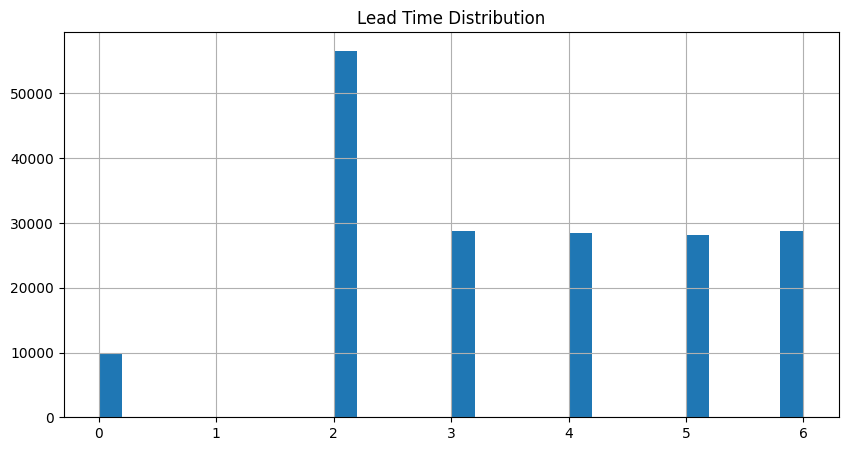

In [4]:
df["lead_time_days"].hist(bins=30, figsize=(10,5))
plt.title("Lead Time Distribution")
plt.show()

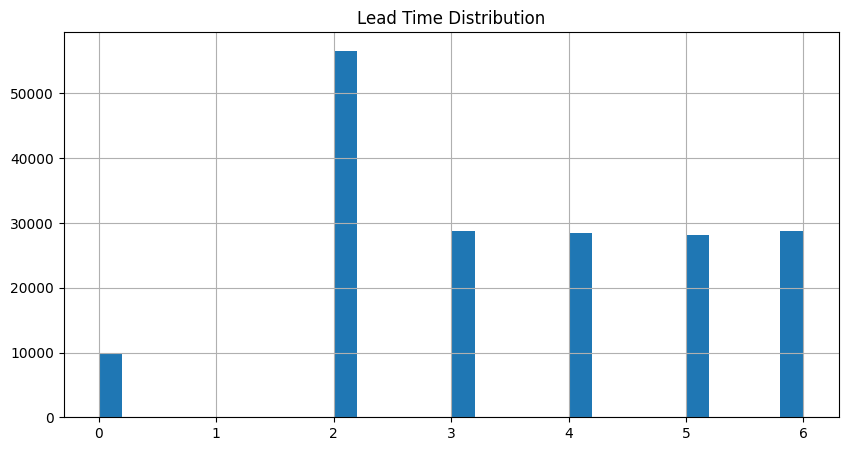

In [5]:
df["lead_time_days"].hist(bins=30, figsize=(10,5))
plt.title("Lead Time Distribution")
plt.show()

In [6]:
df["delivery_status"].value_counts()

delivery_status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [7]:
df["late_delivery_risk"].value_counts(normalize=True)

late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

In [8]:
region_delay = df.groupby("order_region")["late_delivery_risk"].mean()

region_delay.sort_values(ascending=False).head(10)

order_region
Central Africa    0.579606
South Asia        0.562670
East Africa       0.559395
Western Europe    0.558486
South of  USA     0.557726
Eastern Europe    0.556633
East of USA       0.556616
Southeast Asia    0.555299
Central Asia      0.553345
West Asia         0.552837
Name: late_delivery_risk, dtype: float64